# Minimal EnergyPlus 23.2 ↔ BRCM comparison
EnergyPlus and BRCM each run in one code block. BRCM uses the EnergyPlus-exported outside-face temperature of each exterior/ground surface as a surface-specific boundary input. This is a controlled diagnostic, not full predictive equivalence; zone gains, HVAC, infiltration, and ventilation are still omitted from BRCM.

In [1]:
from pathlib import Path
import re, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'src/brcm').is_dir())
Y3_SRC = next(p.resolve() for p in (REPO.parent / 'Y3/src', REPO.parents[1] / 'Y3/src', REPO.parents[1] / '_phd/Y3/src') if (p / 'ReIDF.py').is_file())
sys.path[:0] = [str(REPO / 'src'), str(Y3_SRC)]
from ReIDF import IDFout, run_IDF
import brcm

CASE_NAME = '1ZoneUncontrolled1'
IDF = REPO / '_E+' / f'{CASE_NAME}.idf'
IDD = REPO / '_E+/idd/23.2/Energy+.idd'
EPW = Y3_SRC / '_base/epw/ED-TMYx.2023.epw'
ENERGYPLUS = Path('/Applications/EnergyPlus-23-2-0/EnergyPlus') if sys.platform == 'darwin' else Path('C:/EnergyPlusV23-2-0/EnergyPlus.exe')
WORK = REPO / 'pre_test/outputs/validation/eplus_23_2_minimal' / CASE_NAME
WORK.mkdir(parents=True, exist_ok=True)
print('IDF:', IDF, '\nIDD:', IDD, '\nEPW:', EPW, '\nEnergyPlus:', ENERGYPLUS)

IDF: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/_E+/1ZoneUncontrolled1.idf 
IDD: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/_E+/idd/23.2/Energy+.idd 
EPW: /Users/rui.bo/Desktop/BASE/_phd/Y3/src/_base/epw/ED-TMYx.2023.epw 
EnergyPlus: /Applications/EnergyPlus-23-2-0/EnergyPlus


## 1 — Run EnergyPlus and export comparison signals

In [2]:
working_idf = WORK / IDF.name
shutil.copy2(IDF, working_idf)
window_data = (ENERGYPLUS.parent / 'DataSets/Window5DataFile.dat').resolve()
working_idf.write_text(working_idf.read_text().replace(r'..\datasets\Window5DataFile.dat', str(window_data)), encoding='utf-8')
with working_idf.open('a', encoding='utf-8') as f:
    f.write('''
Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Zone Mean Air Temperature,timestep;
Output:Variable,*,Surface Outside Face Temperature,timestep;
''')
IDFout(working_idf, ['CSV', 'MTR', 'Tabular'])
eplus_dir = Path(run_IDF(working_idf, EPW, ENERGYPLUS))
eplus = pd.read_csv(eplus_dir / 'eplusout.csv')
time_col = next(c for c in eplus if 'date/time' in c.casefold().replace(' ', ''))
zone_cols = {c.split(':', 1)[0].strip().casefold(): c for c in eplus if 'zone mean air temperature' in c.casefold()}
surface_cols = {c.casefold().split(':surface outside face temperature', 1)[0].strip(): c for c in eplus if 'surface outside face temperature' in c.casefold()}
print(f'EnergyPlus: {len(eplus)} samples, {len(zone_cols)} zones, {len(surface_cols)} surface boundary signals')
eplus.head(3)

Simulation completed successfully.
Simulation Output Folder: /Users/rui.bo/Desktop/BASE/_toolkit/pyBRCMToolbox/pre_test/outputs/validation/eplus_23_2_minimal/1ZoneUncontrolled1/1ZoneUncontrolled1
EnergyPlus: 192 samples, 1 zones, 7 surface boundary signals


,Date/Time,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),ZONE ONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep),ZN001:WALL001:Surface Outside Face Sunlit Fraction [](TimeStep),ZN001:WALL001:Surface Outside Face Incident Solar Radiation Rate per Area [W/m2](TimeStep),ZN001:WALL001:WIN001:Surface Outside Face Sunlit Fraction [](TimeStep),ZN001:WALL001:WIN001:Surface Outside Face Incident Solar Radiation Rate per Area [W/m2](TimeStep),ZN001:WALL001:WIN001:Surface Window Transmitted Solar Radiation Rate [W](TimeStep),ZN001:WALL001:Surface Inside Face Temperature [C](TimeStep),ZN001:WALL001:Surface Outside Face Temperature [C](TimeStep),ZN001:WALL002:Surface Outside Face Temperature [C](TimeStep),ZN001:WALL003:Surface Outside Face Temperature [C](TimeStep),ZN001:WALL004:Surface Outside Face Temperature [C](TimeStep),ZN001:FLR001:Surface Outside Face Temperature [C](TimeStep),ZN001:ROOF001:Surface Outside Face Temperature [C](TimeStep),ZN001:WALL001:WIN001:Surface Inside Face Temperature [C](TimeStep),ZN001:WALL001:WIN001:Surface Outside Face Temperature [C](TimeStep),ZONE ONE:Zone Mean Air Temperature [C](TimeStep)
0,12/21 00:15:00,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,-19.066034,-18.250738,-18.250706,-18.200039,-18.250706,-19.150535,-21.703891,-18.941908,-18.782359,-19.145681
1,12/21 00:30:00,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,-19.066051,-18.250738,-18.250707,-18.200039,-18.250707,-19.150555,-21.703892,-18.941919,-18.782364,-19.145698
2,12/21 00:45:00,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,-19.066068,-18.250739,-18.250708,-18.200040,-18.250708,-19.150576,-21.703892,-18.941930,-18.782368,-19.145716


## 2 — Run BRCM using EnergyPlus surface boundary temperatures

In [3]:
result = brcm.convert_idf_to_brcm_data(IDF, idd_path=IDD)
data = brcm.conversion_to_thermal_model_data(result)
model = brcm.generate_thermal_model(data)
x_index = {name: i for i, name in enumerate(model.state_identifiers)}
q_index = {name: i for i, name in enumerate(model.heat_flux_identifiers)}
elements = {element.identifier: element for element in data.building_elements}
zone_pairs = [(z.identifier, z.description, zone_cols[z.description.casefold()]) for z in data.zones]
x0 = np.full(len(x_index), np.mean([eplus[c].iloc[0] for _, _, c in zone_pairs]))
for zone_id, _, column in zone_pairs: x0[x_index['x_' + zone_id]] = eplus[column].iloc[0]

boundary_surface = {}
for group, adjacent in [('ambient', 'AMB'), ('ground', 'GND')]:
    source_elements = [e for e in data.building_elements if e.adjacent_A == adjacent or e.adjacent_B == adjacent]
    boundary_surface.update({id(b): e.description.split(':', 1)[-1].strip().casefold() for b, e in zip(model.boundary_conditions[group], source_elements)})

def energyplus_boundary_flux(x, t, identifiers):
    k = min(int(round(t / 0.25)), len(eplus) - 1)
    q = np.zeros((len(identifiers.q), 1))
    for group in ('ambient', 'ground'):
        for boundary in model.boundary_conditions[group]:
            temperature = eplus[surface_cols[boundary_surface[id(boundary)]]].iloc[k]
            state_name = boundary.identifier_2 if boundary.identifier_1 in ('AMB', 'GND') else boundary.identifier_1
            xi = x_index[state_name]
            qi = q_index['q_' + state_name[2:]]
            q[qi, 0] += boundary.value * (temperature - x[xi, 0])
    return q

brcm_run = brcm.simulate_tm(model, 0.25, x0, len(eplus), energyplus_boundary_flux)
print('BRCM:', brcm_run.X.shape, 'finite:', np.isfinite(brcm_run.X).all(), 'mapped boundaries:', len(model.boundary_conditions['ambient']) + len(model.boundary_conditions['ground']))

BRCM: (2, 192) finite: True mapped boundaries: 5


## 3 — Compare corresponding zone temperatures

,Zone,RMSE [K],CVRMSE [%],NMBE [%],Max |error| [K]
0,ZONE ONE,31.709,363.034,-256.318,54.969


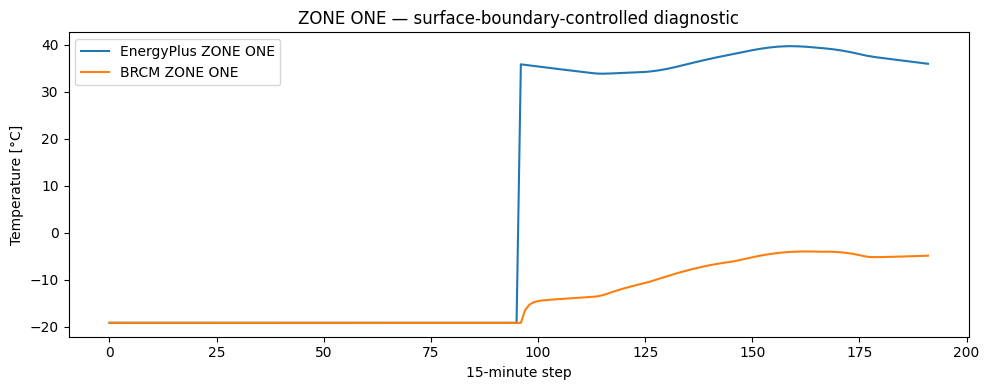

Status: CONTROLLED BOUNDARY DIAGNOSTIC — internal gains, HVAC, infiltration and ventilation remain unmatched.


In [4]:
rows = []
trajectories = pd.DataFrame({'step': np.arange(len(eplus))})
for zone_id, zone_name, column in zone_pairs:
    ep = eplus[column].to_numpy(float)
    rc = brcm_run.X[x_index['x_' + zone_id]]
    error = rc - ep
    rows.append([zone_name, np.sqrt(np.mean(error**2)), 100*np.sqrt(np.mean(error**2))/abs(ep.mean()), 100*error.mean()/ep.mean(), np.max(np.abs(error))])
    trajectories['EnergyPlus ' + zone_name] = ep
    trajectories['BRCM ' + zone_name] = rc
metrics = pd.DataFrame(rows, columns=['Zone', 'RMSE [K]', 'CVRMSE [%]', 'NMBE [%]', 'Max |error| [K]'])
display(metrics.round(3))
zone = zone_pairs[min(1, len(zone_pairs) - 1)][1]
trajectories.plot(x='step', y=['EnergyPlus ' + zone, 'BRCM ' + zone], figsize=(10, 4), title=zone + ' — surface-boundary-controlled diagnostic')
plt.ylabel('Temperature [°C]'); plt.xlabel('15-minute step'); plt.tight_layout(); plt.show()
print('Status: CONTROLLED BOUNDARY DIAGNOSTIC — internal gains, HVAC, infiltration and ventilation remain unmatched.')